#**PROGETTO FINALE JUNIOR DATA ENGINEER** *(DATITA034)* :

*   Adriano Griffo
*   Flavio Laloni
*   Sara Pace
*   Benedetta Simeoni
*   Emanuele Solorzano

#**N.O.W.A.S.T.E.**
#**Network for Optimization of Waste and Surplus Tracking Ecosystem**

Sistema anti-spreco del cibo dove attività con alimenti prossimi alla scadenza (es. ingrossi alimentari,supermercati, minimarket) possono vendere prodotti ad altre attività (mense, banco alimentare, ONLUS) e privati.

Quindi un’applicazione che mette in contatto due categorie:

1.	*VENDITORI*:  Attività che hanno prodotti in scadenza.
2.	*ACQUIRENTI*: Attività/privati che possono acquistare i prodotti in scadenza.



Per la nostra applicazione abbiamo pensato al seguente schema ER:

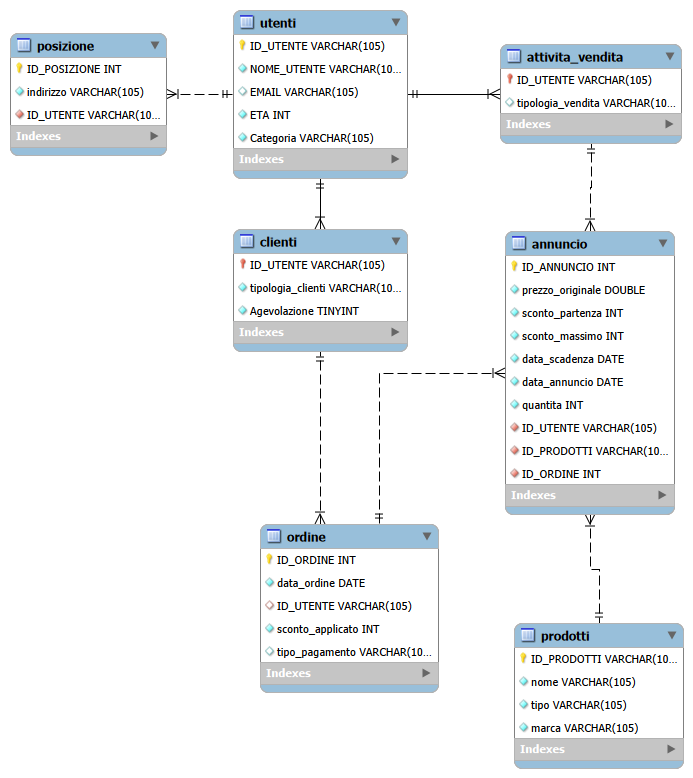

Il database prende dati di una serie di utenti con base a Roma. Per ogni utente è riportato il tipo di attività (clienti e attività di vendita).

Dopo una prima pulizia dei file csv in **Excel**, abbiamo creato un database su **MySQL**. Prima di importare i file abbiamo impostato delle regole per il database:


*  L'utente si può registrare solo con p.iva(11 caratteri) o con codice fiscale(16 caratteri).

*   Se l'utente si registra con CF, la sua categoria è obbligatoriamente "Acquisto".

*   L'utente per registrarsi deve essere maggiorenne.

*   L'utente che si registra come Privato non gode di alcuna agevolazione.
*   Solo Le attività benefiche godono di agevolazioni.


*   Data di scadenza del prodotto - data dell'annuncio <= 3 giorni.


Per facilitare l'utilizzo dell'APP abbiamo aggiunto:



*   **VIEWS:**

   *1.*   Catalogo_Annuncio

  *2.*   Storico_Acquisti


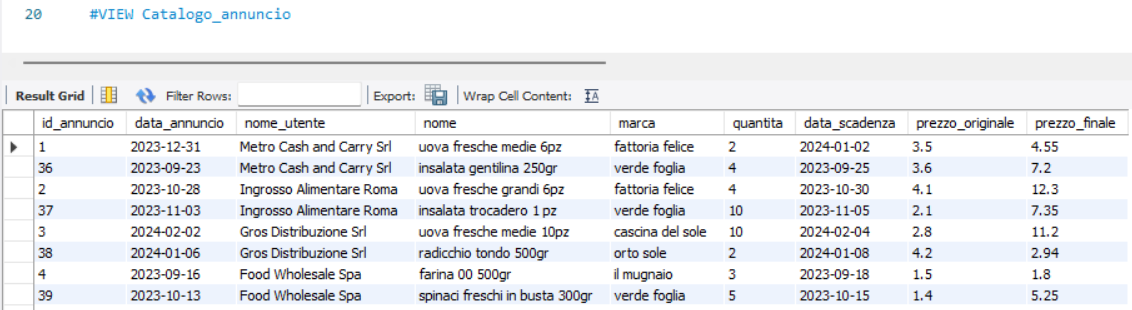



*   **STORED PROCEDURES:**


*1.*   Aggiungi_Utente

*2.*   AggiungiProdotti

*3.*  EliminaOrdine

*4.*  Modifica_Annuncio






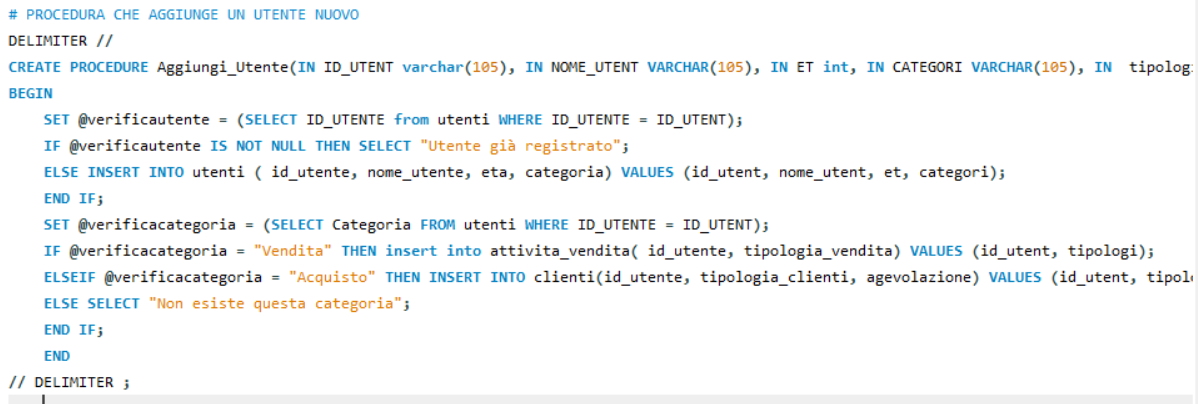



*   **FUNZIONI**


*1.* Totale_Ordine: questa funzione calcola il totale da pagare, tenendo conto della quantità del prodotto e dello sconto applicato.

*2.* QuantitaPerTipo


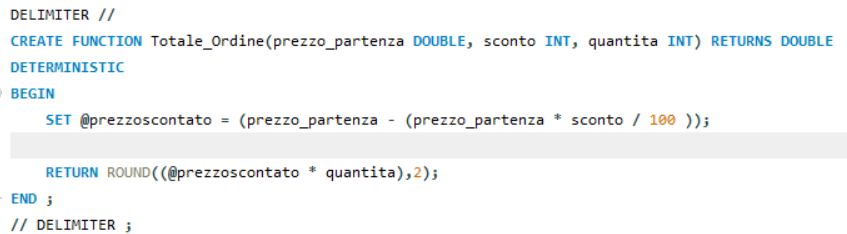

Alcune procedure e funzioni sono state eseguite su **GoogleColab**, facendo comunicare **Python** e **SQL** attraverso la libreria **mysql-connector-python**.

In [ ]:
!pip install mysql-connector-python
import mysql.connector
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 57.1 MB/s eta 0:00:00


In [ ]:
USER = 'root'
PASSWORD = '25DATITA034!'
HOST = '2.tcp.eu.ngrok.io'
PORT = 11385
DATABASE = 'food_waste'

Funzione per stabilire la connessione tra Python e MySQL:

In [ ]:
def stabilisci():
  conn = mysql.connector.connect(
  user=USER,
  password=PASSWORD,
  host=HOST,
  port=PORT,
  database=DATABASE )
  print("Connessione con " , DATABASE, "avvenuta con successo")
  return conn

Tramite **query** abbiamo estratto dei dati dal nostro database e li abbiamo inseriti in un dataframe.

In [ ]:
varConnessione = stabilisci()
query = "SELECT * FROM prodotti"
df = pd.read_sql(query, varConnessione)
df


Connessione con  food_waste avvenuta con successo


/tmp/ipykernel_27920/3111904999.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, varConnessione)


,ID_prodotti,nome,tipo,marca
0,10293816,macinato scelto di manzo 300gr,carne,macelleria tradizione
1,10293817,merluzzo fresco filetti 400gr,pesce,pescato d oro
2,10293818,tonno all olio di oliva 3x80gr,conserva,mare blu
3,10293836,aceto di vino bianco 1L,condimento,acetaia ducale
4,10293837,penne rigate di grano duro 500gr,pasta,pastaia d italia
...,...,...,...,...
250,95847312,ceci secchi 1kg,legumi,campo verde
251,95847332,pane bauletto ai cereali 400gr,pane,gran forno
252,95847352,preparato per risotto di mare surgelato 300gr,pesce,capitan mare
253,95847362,farina manitoba 1kg,farina,il mugnaio


La *procedura* AggiungiProdotti permette all'utente di inserire n prodotti.

In [ ]:
def AggiungiProdotti():
  conn=stabilisci()
  mycursor=conn.cursor()
  numero= int(input("Quanti prodotti vuoi aggiungere? "))
  for i in range(numero):
    ID = input("Inserisci il codice da aggiungere: ")
    nome = input("Inserisci il nome del prodotto: ")
    tipo = input("Inserisci il tipo di prodotto: " )
    marca = input("Inserisci la marca del prodotto: ")
    query = f"INSERT INTO prodotti (ID_prodotti, nome, tipo, marca) VALUES ('{ID}','{nome}','{tipo}','{marca}')"
    mycursor.execute(query)
  conn.commit()
  conn.close()
  print(f"Sono stati aggiunti {numero} prodotti")

Abbiamo scritto del codice per visualizzare il numero di prodotti per categoria.  

In [ ]:
conn = stabilisci()
query = "SELECT tipo, COUNT(*) AS Numero_Prodotti FROM prodotti GROUP BY tipo"
df = pd.read_sql(query, conn)
df

Connessione con  food_waste avvenuta con successo


/tmp/ipykernel_27920/807226578.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,tipo,Numero_Prodotti
0,carne,19
1,pesce,12
2,conserva,14
3,condimento,22
4,pasta,14
5,uova,10
6,ortofrutta,76
7,latte,9
8,cereali,8
9,latticino,12


Abbiamo trasformato il codice sopra, in una *FUNZIONE* che, scelto il tipo, mi restituisce il numero di prodotti.

In [ ]:
def QuantitaPerTipo():
  conn = stabilisci()
  scelta = input("Di quale tipo vuoi vedere il numero di prodotto? ")
  query = f"SELECT tipo, COUNT(*) AS Numero_Prodotti FROM prodotti WHERE tipo = '{scelta}'"
  df = pd.read_sql(query, conn)
  return df


In [ ]:
df = QuantitaPerTipo()
df


Connessione con  food_waste avvenuta con successo
Di quale tipo vuoi vedere il numero di prodotto? carne


/tmp/ipykernel_27920/2404781871.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,tipo,Numero_Prodotti
0,carne,19


In [ ]:
def EliminaOrdine(ID_ORDINE):
  conn = stabilisci()
  mycursor = conn.cursor()
  query = f"DELETE FROM ordine WHERE ID_ORDINE = '{ID_ORDINE}'"
  mycursor.execute(query)
  conn.commit()
  conn.close()
  print (f"Ordine numero {ID_ORDINE} cancellato")


La *PROCEDURA* permette di modificare l'annuncio: possiamo scegliere se cambiare la quantità, il prezzo o entrambi contemporaneamente.

In [ ]:
def Modifica_Annuncio():
  conn = stabilisci()
  mycursor = conn.cursor()
  annunciomodificato = int(input("Quale ID ANNUNCIO vuoi modificare? "))
  scelta = input("Cosa vuoi modificare? 1. Quantità, 2. Prezzo, 3. Quantità e Prezzo")
  if scelta == "1":
    nuovaquantita = int(input("Inserisci nuova quantità: "))
    query = f"UPDATE annunci SET quantita = {nuovaquantita} WHERE ID_ANNUNCIO = {annunciomodificato}"
  elif scelta == "2":
    nuovoprezzo = float(input("Inserisci il nuovo prezzo: "))
    query = f"UPDATE annunci SET prezzo_originale = {nuovoprezzo} WHERE ID_ANNUNCIO = {annunciomodificato}"
  elif scelta == "3":
    nuovaquantitaprezzo = int(input("Inserisci nuova quantità: "))
    nuovoprezzoquantita= float(input("Inserisci il nuovo prezzo: "))
    query = f"UPDATE annunci SET quantita = {nuovaquantitaprezzo}, prezzo_originale = {nuovoprezzoquantita} WHERE ID_ANNUNCIO = {annunciomodificato}"
  else:
    print("Hai inserito un'opzione non valida. ")
  mycursor.execute(query)
  conn.commit()
  conn.close()
  print(f"L'annuncio è stato modificato")



##**ANALISI STATISTICA ED ESPLORATIVA SUI DATI CONTENTUTI NEL DATABASE Food_Waste**





Siamo partiti dall'osservare la distribuzione dell'età nel nostro database, illustrando i dati attraverso un *istogramma*.

Connessione con  food_waste avvenuta con successo


/tmp/ipykernel_27920/2511589254.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


<function matplotlib.pyplot.show(close=None, block=None)>

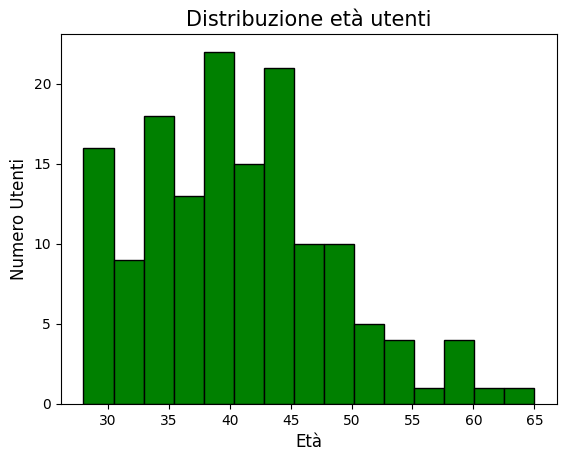

In [ ]:
conn = stabilisci()
mycursor = conn.cursor()
query = "SELECT * FROM utenti"
df = pd.read_sql(query, conn)
plt.hist(df['ETA'], bins=15, edgecolor = "Black", color = "green")
plt.title('Distribuzione età utenti', fontsize= 15)
plt.xlabel("Età", fontsize=12)
plt.ylabel("Numero Utenti", fontsize=12)
plt.show

Il numero maggiore di utenti si concentra intorno ai 40 anni.

Abbiamo calcolato alcuni parametri statistici ( Asimmetria e Curtosi).

In [ ]:
asimmetria = df['ETA'].skew()
asimmetria

np.float64(0.5794869752348333)

In [ ]:
curtosi = df['ETA'].kurt()
curtosi

np.float64(0.11419096705942655)

Per ogni prodotto nella tabella Annunci, vediamo il prezzo di partenza.


In [ ]:
conn = stabilisci()
mycursor = conn.cursor()
query = '''SELECT nome, prezzo_originale FROM annunci
JOIN prodotti ON prodotti.ID_prodotti = annunci.ID_PRODOTTI
'''
df = pd.read_sql(query, conn)
df

Connessione con  food_waste avvenuta con successo


/tmp/ipykernel_27920/3771830158.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,nome,prezzo_originale
0,uova fresche medie 6pz,3.50
1,uova fresche grandi 6pz,4.10
2,uova fresche medie 10pz,2.80
3,farina 00 500gr,1.50
4,farina 00 1kg,5.00
5,farina di mais per polenta 1kg,2.20
6,latte intero fresco 1L,1.80
7,latte intero fresco alta qualita 1L,3.90
8,burro classico 125gr,6.50
9,mozzarella fiordilatte 3x100gr,4.50


Creiamo un *Boxplot* per visualizzare il costo iniziale per ogni tipo di prodotto.

Connessione con  food_waste avvenuta con successo


/tmp/ipykernel_27920/2426055746.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


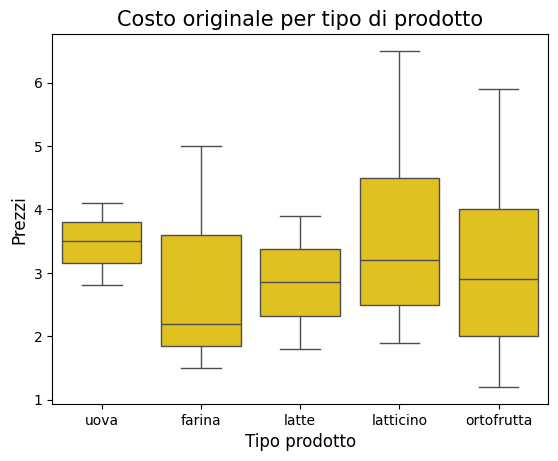

In [ ]:
conn = stabilisci()
mycursor = conn.cursor()
query = '''SELECT tipo, prezzo_originale FROM annunci
JOIN prodotti ON prodotti.ID_prodotti = annunci.ID_PRODOTTI
'''
df = pd.read_sql(query, conn)
sns.boxplot(df, x = "tipo", y="prezzo_originale", color= "Gold")
plt.title("Costo originale per tipo di prodotto", fontsize= 15)
plt.xlabel("Tipo prodotto", fontsize = 12)
plt.ylabel("Prezzi", fontsize = 12)
plt.show()

Dal grafico possiamo vedere che le uova hanno il prezzo medio più stabile, così come il latte.
Latticino, Ortofrutta e Farina hanno oscillazioni di prezzo maggiori.

#**EDA SULLO SPRECO ALIMENTARE**

In [ ]:
df = pd.read_csv("/content/sample_data/Spechi_food_service_house_retail.csv", sep=";", decimal=",")

In [ ]:
df.head()

,Region,Country,Retail_estimate_(kg/capita/year),Retail_estimate_(tonnes/year),Food_service_estimate_(kg/capita/year),Food_service_estimate_(tonnes/year),Household_estimate_(kg/capita/year),Household_estimate_(tonnes/year),Population,Total _Waste_(tonnes/year),perc_waste_retail,perc_waste_food,Perc_waste_house
0,Australia and New Zealand,Australia,9.453072,238247.6705,21.677392,546339.6344,101.697811,2.563110e+06,25203200.01,3.347698e+06,7,16,77
1,Australia and New Zealand,New Zealand,3.120000,14923.2720,25.570418,122305.8664,61.000000,2.917691e+05,4783100.00,4.289982e+05,3,29,68
2,Central Asia,Kazakhstan,15.640229,290148.1368,27.648075,512910.4905,75.713119,1.404584e+06,18551400.01,2.207643e+06,13,23,64
3,Central Asia,Kyrgyzstan,15.640229,100346.1426,27.648075,177387.2816,91.016180,5.839507e+05,6415900.00,8.616841e+05,12,21,68
4,Central Asia,Tajikistan,15.640229,145782.5707,27.648075,257707.7030,97.222251,9.062086e+05,9321000.00,1.309699e+06,11,20,69


Controlliamo la **struttura dei dati** della tabella e le **dimensioni**.

In [ ]:
print(f"Data type: {type(df)}\n")
print(f"{df.dtypes}\n")
print("Number of rows: ", df.shape[0])
print("Number of columns: ", df.shape[1])

Data type: <class 'pandas.core.frame.DataFrame'>

Region                                     object
Country                                    object
Retail_estimate_(kg/capita/year)          float64
Retail_estimate_(tonnes/year)             float64
Food_service_estimate_(kg/capita/year)    float64
Food_service_estimate_(tonnes/year)       float64
Household_estimate_(kg/capita/year)       float64
Household_estimate_(tonnes/year)          float64
Population                                float64
Total _Waste_(tonnes/year)                float64
perc_waste_retail                           int64
perc_waste_food                             int64
Perc_waste_house                            int64
dtype: object

Number of rows:  201
Number of columns:  13


Verifichiamo se all'interno del dataset sono presenti valori nulli.

In [ ]:
missing_values = df.isnull().sum()
print(missing_values)

Region                                    0
Country                                   0
Retail_estimate_(kg/capita/year)          0
Retail_estimate_(tonnes/year)             0
Food_service_estimate_(kg/capita/year)    0
Food_service_estimate_(tonnes/year)       0
Household_estimate_(kg/capita/year)       0
Household_estimate_(tonnes/year)          0
Population                                0
Total _Waste_(tonnes/year)                0
perc_waste_retail                         0
perc_waste_food                           0
Perc_waste_house                          0
dtype: int64


Siamo partiti dall'analisi di indici di statistica descrittiva.

In [ ]:
display(df.describe())

,Retail_estimate_(kg/capita/year),Retail_estimate_(tonnes/year),Food_service_estimate_(kg/capita/year),Food_service_estimate_(tonnes/year),Household_estimate_(kg/capita/year),Household_estimate_(tonnes/year),Population,Total _Waste_(tonnes/year),perc_waste_retail,perc_waste_food,Perc_waste_house
count,201.000000,2.010000e+02,201.000000,2.010000e+02,201.000000,2.010000e+02,2.010000e+02,2.010000e+02,201.000000,201.000000,201.000000
mean,14.852002,5.368276e+05,26.880862,1.063525e+06,84.690880,2.595252e+06,3.497560e+07,4.195604e+06,11.810945,21.562189,66.761194
std,5.928175,2.237518e+06,6.171837,5.365935e+06,18.587880,8.752903e+06,1.429295e+08,1.614768e+07,2.953655,4.516344,5.852579
min,3.120000,1.383621e+02,3.339154,2.761605e+02,33.375521,8.498556e+02,1.080000e+04,1.264378e+03,3.000000,4.000000,35.000000
25%,12.811309,1.193506e+04,25.570418,2.164291e+04,73.920770,6.096264e+04,7.828000e+05,9.303347e+04,11.000000,19.000000,64.000000
50%,15.640229,1.003461e+05,27.648075,1.873848e+05,80.671375,5.131457e+05,6.777500e+06,7.961935e+05,11.000000,22.000000,67.000000
75%,15.640229,3.178313e+05,27.648075,5.618476e+05,97.222251,2.075405e+06,2.331070e+07,3.181574e+06,13.000000,23.000000,70.000000
max,78.817370,2.242470e+07,89.563549,6.537774e+07,188.797725,9.164621e+07,1.433784e+09,1.794487e+08,30.000000,45.000000,81.000000


Con il Boxplot siamo andati a vedere lo spreco alimentare annuo per persona per ogni regione.




/tmp/ipykernel_2198/2688975251.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x="Region", y="Household_estimate_(kg/capita/year)", palette="Greens")


<function matplotlib.pyplot.show(close=None, block=None)>

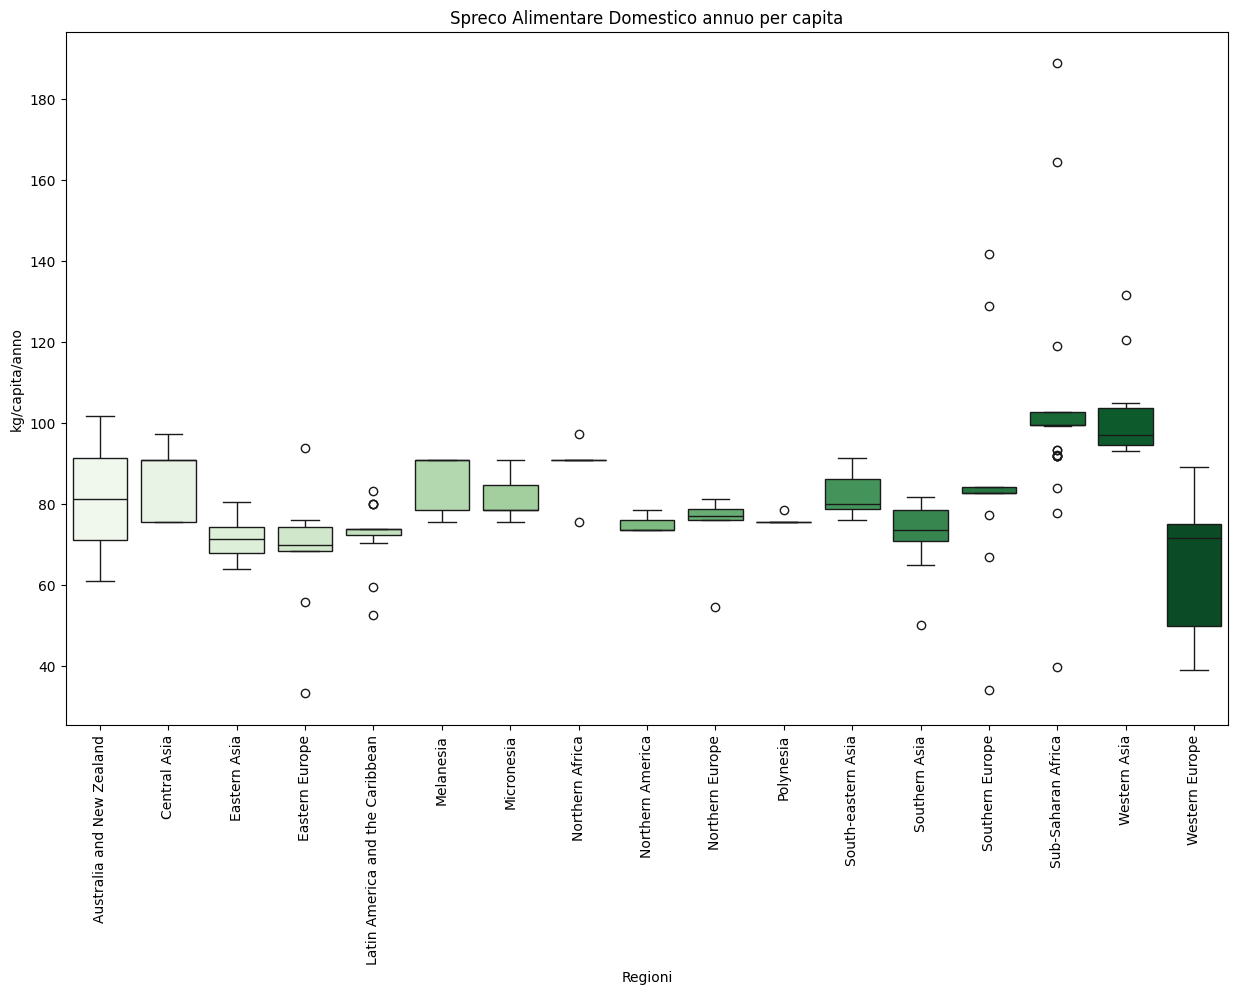

In [ ]:
plt.figure(figsize=(15,9))
sns.boxplot(df, x="Region", y="Household_estimate_(kg/capita/year)", palette="Greens")
plt.xticks(rotation = 90)
plt.title("Spreco Alimentare Domestico annuo per capita")
plt.xlabel("Regioni")
plt.ylabel("kg/capita/anno")

plt.show

Con il secondo Boxplot siamo andati a vedere lo spreco alimentare annuo totale per ogni regione.


/tmp/ipykernel_2198/2857507173.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, y="Region", x="Household_estimate_(tonnes/year)", palette = "Greens")


<function matplotlib.pyplot.show(close=None, block=None)>

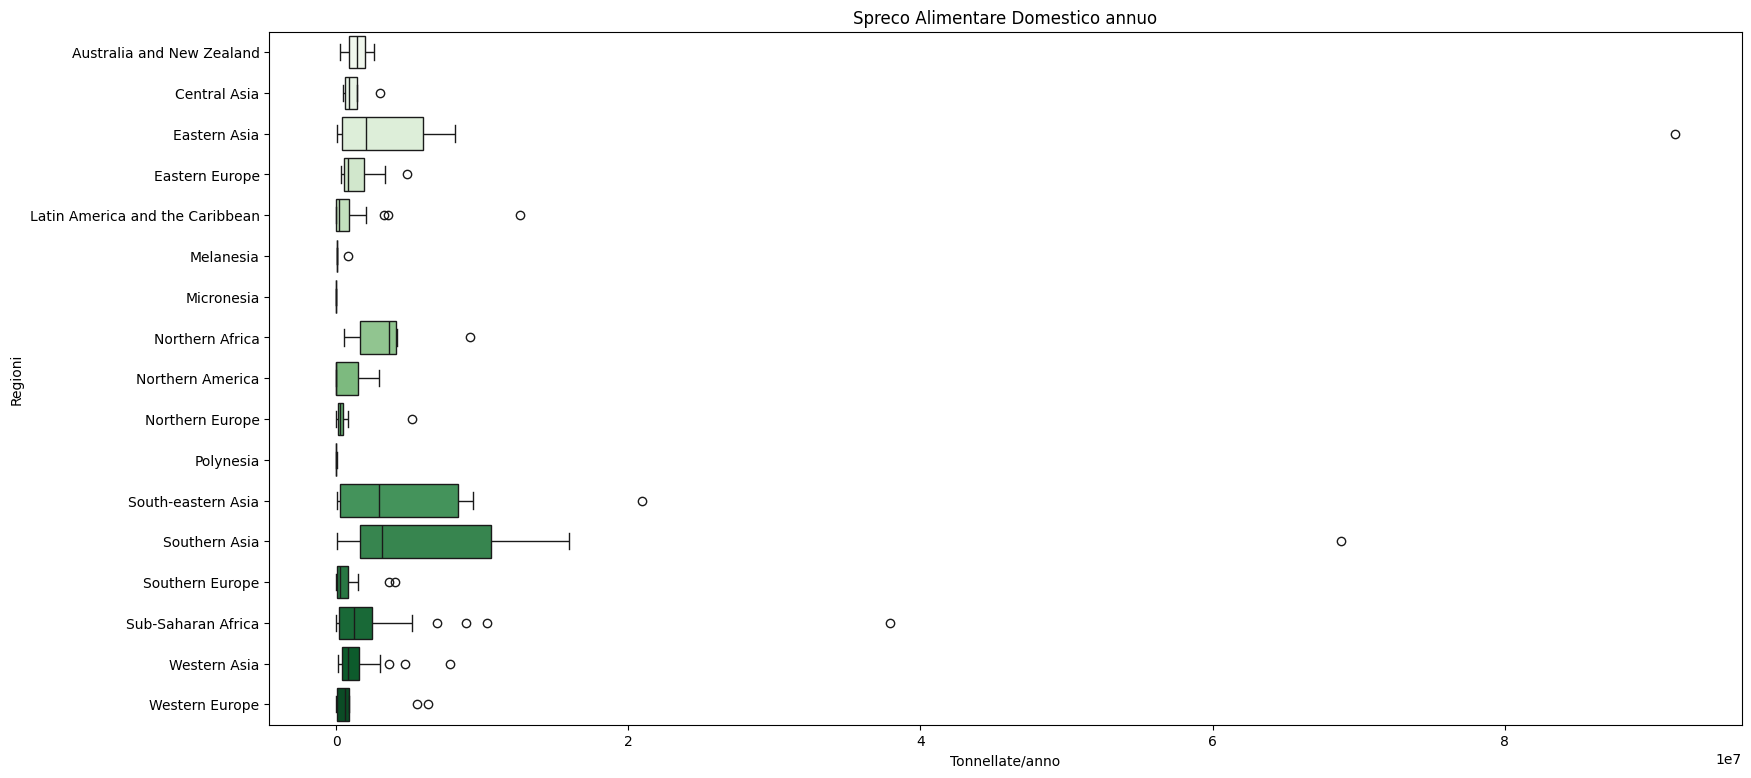

In [ ]:
plt.figure(figsize=(19,9))
sns.boxplot(df, y="Region", x="Household_estimate_(tonnes/year)", palette = "Greens")
plt.title("Spreco Alimentare Domestico annuo")
plt.ylabel("Regioni")
plt.xlabel("Tonnellate/anno")
plt.show

Analisi di correlazione tramite Heatmap.



In [ ]:
sezione = df.select_dtypes(include=['number'])
sezione
matrice_correlazione= sezione.corr()
matrice_correlazione

,Retail_estimate_(kg/capita/year),Retail_estimate_(tonnes/year),Food_service_estimate_(kg/capita/year),Food_service_estimate_(tonnes/year),Household_estimate_(kg/capita/year),Household_estimate_(tonnes/year),Population,Total _Waste_(tonnes/year),perc_waste_retail,perc_waste_food,Perc_waste_house
Retail_estimate_(kg/capita/year),1.000000,0.090391,0.628623,0.041532,0.149639,0.031406,0.020603,0.043350,0.788067,0.026631,-0.424064
Retail_estimate_(tonnes/year),0.090391,1.000000,0.195014,0.966361,-0.128026,0.963836,0.996288,0.982142,0.163586,0.246078,-0.276758
Food_service_estimate_(kg/capita/year),0.628623,0.195014,1.000000,0.216336,0.055174,0.152828,0.140530,0.181752,0.306181,0.559781,-0.600852
Food_service_estimate_(tonnes/year),0.041532,0.966361,0.216336,1.000000,-0.121853,0.951470,0.966521,0.981956,0.090234,0.275419,-0.265440
Household_estimate_(kg/capita/year),0.149639,-0.128026,0.055174,-0.121853,1.000000,-0.010279,-0.138777,-0.063804,-0.306776,-0.666907,0.666253
Household_estimate_(tonnes/year),0.031406,0.963836,0.152828,0.951470,-0.010279,1.000000,0.967009,0.991785,0.064278,0.170570,-0.169473
Population,0.020603,0.996288,0.140530,0.966521,-0.138777,0.967009,1.000000,0.983401,0.112675,0.237416,-0.243428
Total _Waste_(tonnes/year),0.043350,0.982142,0.181752,0.981956,-0.063804,0.991785,0.983401,1.000000,0.087494,0.218079,-0.218419
perc_waste_retail,0.788067,0.163586,0.306181,0.090234,-0.306776,0.064278,0.112675,0.087494,1.000000,0.186422,-0.640695
perc_waste_food,0.026631,0.246078,0.559781,0.275419,-0.666907,0.170570,0.237416,0.218079,0.186422,1.000000,-0.869584


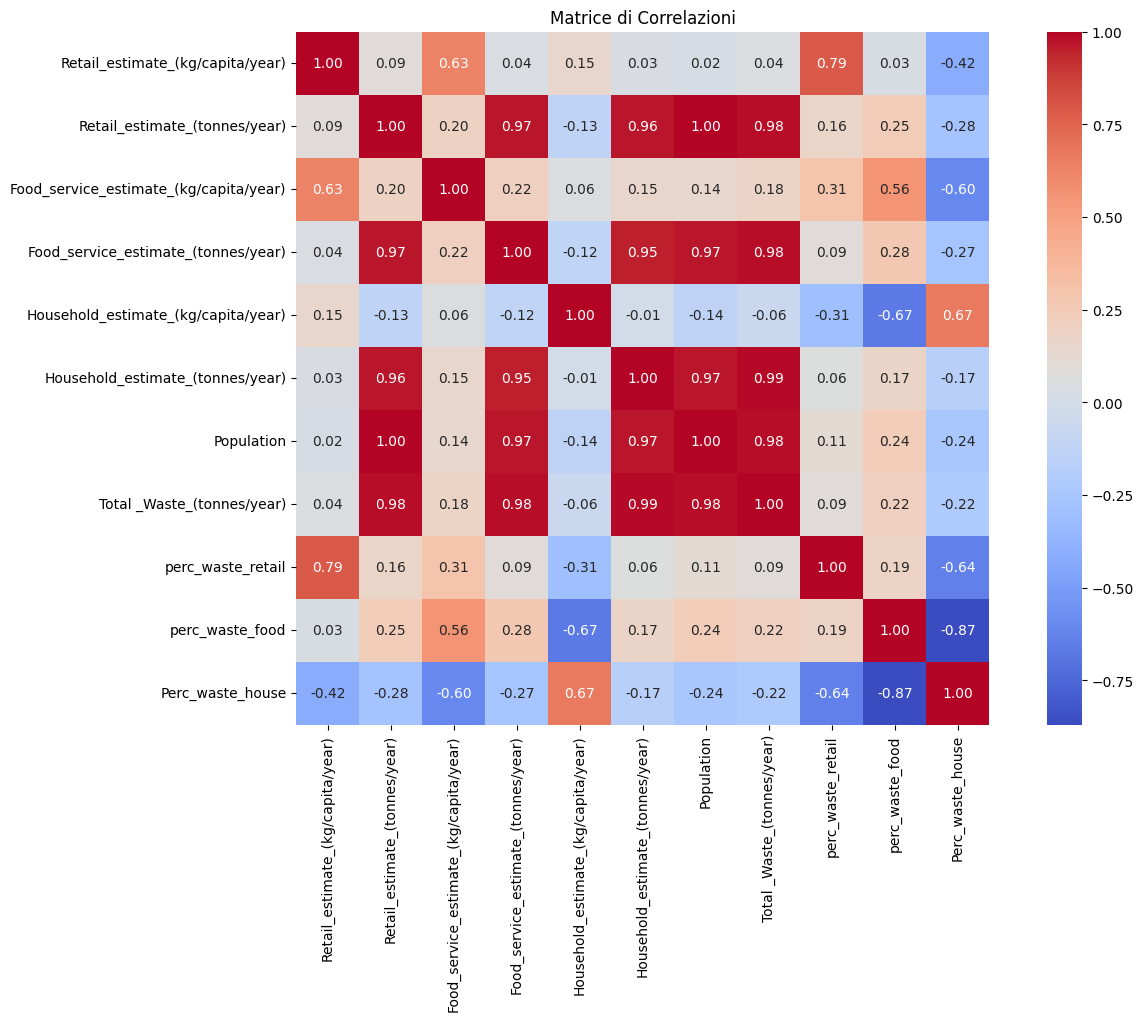

In [ ]:
plt.figure(figsize=(15,9))
sns.heatmap(matrice_correlazione,
            cmap="coolwarm",
            fmt = ".2f",
            annot = True,
            square=True)
plt.title("Matrice di Correlazioni")
plt.show()

Andiamo a considerare i 10 Paesi che sprecano più cibo e i 10 Paesi che sprecano meno tramite due grafici a colonna.

In [ ]:
top10paesi = df.sort_values(by = "Retail_estimate_(kg/capita/year)", ascending = False).head(10)
top10paesi

,Region,Country,Retail_estimate_(kg/capita/year),Retail_estimate_(tonnes/year),Food_service_estimate_(kg/capita/year),Food_service_estimate_(tonnes/year),Household_estimate_(kg/capita/year),Household_estimate_(tonnes/year),Population,Total _Waste_(tonnes/year),perc_waste_retail,perc_waste_food,Perc_waste_house
97,South-eastern Asia,Malaysia,78.817370,2.518199e+06,89.563549,2.861537e+06,91.442717,2.921577e+06,3.194980e+07,8.301313e+06,30,34,35
180,Western Asia,Israel,51.411711,4.379969e+05,27.437619,2.337520e+05,99.583919,8.483952e+05,8.519400e+06,1.520144e+06,29,15,56
81,Northern Europe,Denmark,29.800000,1.720026e+05,20.640390,1.191343e+05,81.333528,4.694490e+05,5.771900e+06,7.605859e+05,23,16,62
194,Western Europe,France,25.603799,1.667568e+06,24.483138,1.594579e+06,84.790172,5.522358e+06,6.512970e+07,8.784506e+06,19,18,63
186,Western Asia,Saudi Arabia,19.653668,6.735017e+05,25.570418,8.762599e+05,104.880000,3.594080e+06,3.426850e+07,5.143842e+06,13,17,70
7,Eastern Asia,China,15.640229,2.242470e+07,45.598050,6.537774e+07,63.919134,9.164621e+07,1.433784e+09,1.794487e+08,12,36,51
3,Central Asia,Kyrgyzstan,15.640229,1.003461e+05,27.648075,1.773873e+05,91.016180,5.839507e+05,6.415900e+06,8.616841e+05,12,21,68
4,Central Asia,Tajikistan,15.640229,1.457826e+05,27.648075,2.577077e+05,97.222251,9.062086e+05,9.321000e+06,1.309699e+06,11,20,69
2,Central Asia,Kazakhstan,15.640229,2.901481e+05,27.648075,5.129105e+05,75.713119,1.404584e+06,1.855140e+07,2.207643e+06,13,23,64
67,Micronesia,Marshall Islands,15.640229,9.196454e+02,27.648075,1.625707e+03,75.713119,4.451931e+03,5.880000e+04,6.997284e+03,13,23,64


/tmp/ipykernel_2198/1828099910.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(top10paesi, x = "Country", y ="Retail_estimate_(kg/capita/year)", palette = "Greens_r")


<function matplotlib.pyplot.show(close=None, block=None)>

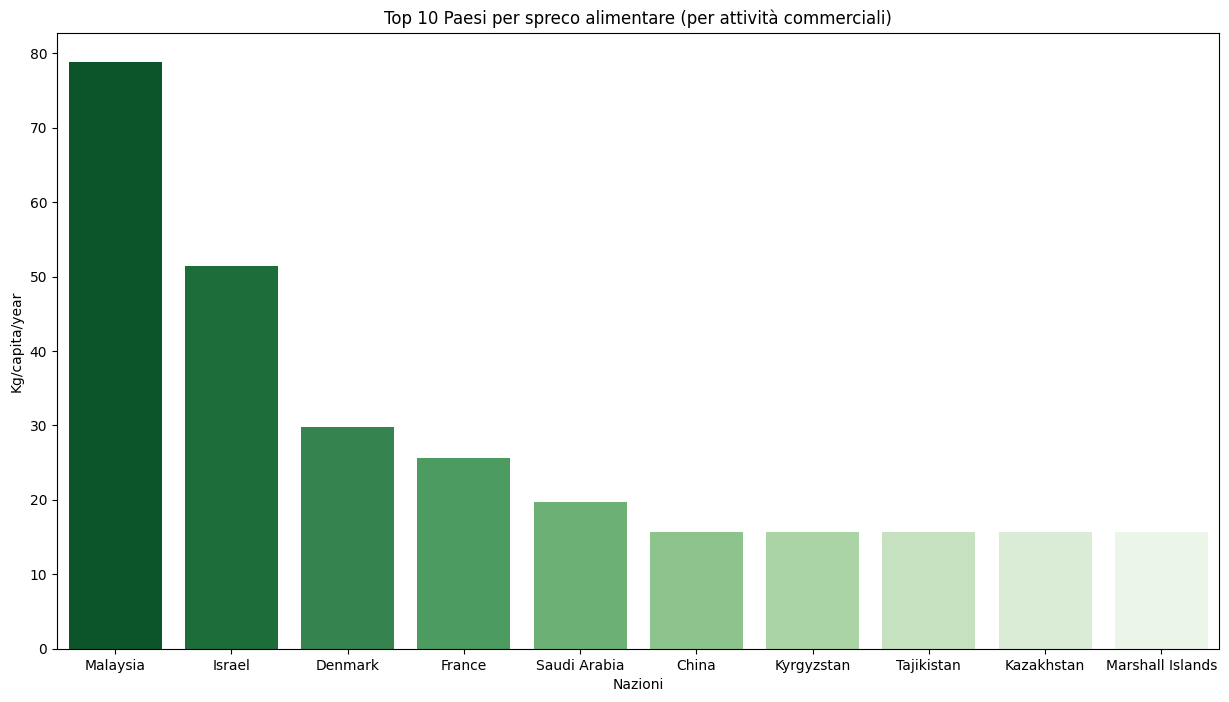

In [ ]:
plt.figure(figsize=(15,8))
sns.barplot(top10paesi, x = "Country", y ="Retail_estimate_(kg/capita/year)", palette = "Greens_r")
plt.title("Top 10 Paesi per spreco alimentare (per attività commerciali)")
plt.xlabel("Nazioni")
plt.ylabel("Kg/capita/year")
plt.show

In [ ]:
Lowest10Paesi = df.sort_values(by ="Retail_estimate_(kg/capita/year)", ascending = False).tail(10)
ordinati = Lowest10Paesi.sort_values(by ="Retail_estimate_(kg/capita/year)", ascending = True)
ordinati

,Region,Country,Retail_estimate_(kg/capita/year),Retail_estimate_(tonnes/year),Food_service_estimate_(kg/capita/year),Food_service_estimate_(tonnes/year),Household_estimate_(kg/capita/year),Household_estimate_(tonnes/year),Population,Total _Waste_(tonnes/year),perc_waste_retail,perc_waste_food,Perc_waste_house
1,Australia and New Zealand,New Zealand,3.120000,1.492327e+04,25.570418,1.223059e+05,61.000000,2.917691e+05,4783100.0,4.289982e+05,3,29,68
117,Southern Europe,Italy,3.625953,2.195518e+05,25.570418,1.548291e+06,67.048711,4.059806e+06,60550100.0,5.827649e+06,4,27,70
89,Northern Europe,United Kingdom,4.200000,2.836268e+05,16.500000,1.114248e+06,77.000000,5.199825e+06,67530200.0,6.597701e+06,4,17,79
82,Northern Europe,Estonia,4.709408,6.242791e+03,16.605743,2.201257e+04,77.507163,1.027435e+05,1325600.0,1.309989e+05,5,17,78
195,Western Europe,Germany,5.965778,4.982439e+05,20.575845,1.718433e+06,75.000000,6.263775e+06,83517000.0,8.480452e+06,6,20,74
124,Southern Europe,Slovenia,6.691769,1.391018e+04,20.080269,4.174085e+04,34.207218,7.110654e+04,2078700.0,1.267576e+05,11,33,56
197,Western Europe,Luxembourg,7.200000,4.433040e+03,20.900000,1.286813e+04,89.250000,5.495122e+04,615700.0,7.225240e+04,6,18,76
116,Southern Europe,Greece,7.383543,7.733153e+04,25.570418,2.678118e+05,141.690544,1.483996e+06,10473500.0,1.829139e+06,4,15,81
192,Western Europe,Austria,8.630716,7.728893e+04,28.385022,2.541907e+05,39.000000,3.492489e+05,8955100.0,6.807285e+05,11,37,51
11,Eastern Asia,Japan,8.633966,1.095308e+06,14.746422,1.870735e+06,64.321866,8.159891e+06,126860300.0,1.112593e+07,10,17,73


/tmp/ipykernel_2198/1571591775.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ordinati, x = "Country", y ="Retail_estimate_(kg/capita/year)", palette = "Greens")


<function matplotlib.pyplot.show(close=None, block=None)>

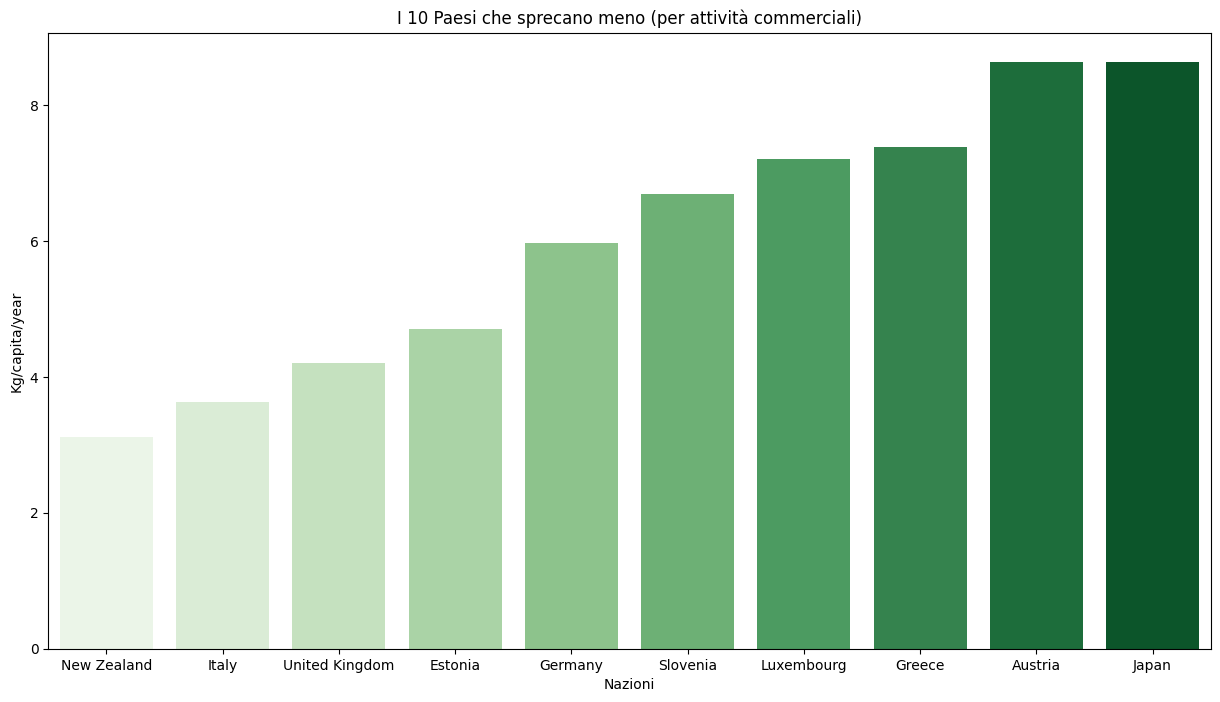

In [ ]:
plt.figure(figsize=(15,8))
sns.barplot(ordinati, x = "Country", y ="Retail_estimate_(kg/capita/year)", palette = "Greens")
plt.title("I 10 Paesi che sprecano meno (per attività commerciali)")
plt.xlabel("Nazioni")
plt.ylabel("Kg/capita/year")
plt.show

**Considerazioni:**


Lo spreco alimentare è un fenomeno Paese dipendente. Fattori culturali potrebbero essere responsabili di tale trend.

In base a questo abbiamo identificato Paesi target in cui una maggiore gestione delle risorse alimentari potrà essere più incisiva.

Dalle analisi si evince che l'Asia non ha, in generale, una buona gestione degli sprechi alimentare.

Future indagine sullo stato di sviluppo del Paese potrebbero chiarire ulteriori correlazioni con lo spreco alimentare.
Un'altra via esplorativa potrebbe riguardare le abitudini dei diversi Paesi, mostrando una correlazione con lo spreco alimentare.
